# Zero-kernel coupling ≡ diagonal Gaussianization

A coupling flow with mixture-CDF blocks normally captures cross-dim dependence via the conditioner. But when the conditioner is *zero-initialised* — specifically, when the **final** Dense of the conditioner has kernel $W = 0$ — something interesting happens: the flow collapses into a plain diagonal Gaussianization flow.

This notebook:

1. Recaps the four objects at play (the mixture-CDF primitive, the diagonal Gaussianization flow, iterative vs parametric training, the coupling flow).
2. Works through the math showing the equivalence (Lemmas 1–3 → Theorem → Corollary).
3. Verifies it empirically: build matched diagonal and coupling flows, IG-initialise both, compare pushforwards element-wise.
4. Shows that a single gradient step is enough for the coupling flow to *break* the equivalence — its conditioner starts modulating on $x_a$ and the flow becomes strictly more expressive.

The upshot: IG init on a coupling flow gives you the best of both worlds — a well-understood RBIG starting point *and* a conditioner waiting to do cross-dim work once training begins.

## 1. Mathematical recap

Self-contained summary of the pieces so this notebook stands on its own.

### Notation and shapes

- $d$ — data dimensionality, $K$ — mixture components per marginal, $N$ — batch size, $L$ — number of blocks in the flow.
- Random vector $X \sim p_X$ on $\mathbb{R}^d$ (what we have data from). Latent $Z \sim p_Z = \mathcal{N}(0, I_d)$ (what we want the flow to land on).
- Bijective map $f: \mathbb{R}^d \to \mathbb{R}^d$ with Jacobian $J_f(x) \in \mathbb{R}^{d \times d}$.

### Change of variables (the one identity behind everything)

For a bijection $z = f(x)$ and any base density $p_Z$,
$$\log p_X(x) \;=\; \log p_Z\!\big(f(x)\big) \;+\; \log\lvert\det J_f(x)\rvert.$$
Training minimises the negative of this averaged over data — the NLL.

### 1-D mixture-CDF Gaussianization (the primitive)

Classical probability integral transform: if $X$ has strictly increasing CDF $F$, then $F(X) \sim \text{Uniform}[0, 1]$, so $\Phi^{-1}(F(X)) \sim \mathcal{N}(0, 1)$. We approximate $F$ with a mixture of $K$ normals,
$$F(x;\,\pi, \mu, \sigma) \;=\; \sum_{k=1}^{K} \pi_k \,\Phi\!\big((x - \mu_k)/\sigma_k\big), \qquad f(x;\,\pi, \mu, \sigma) \;=\; \sum_{k=1}^{K} \pi_k\,\sigma_k^{-1}\,\varphi\!\big((x - \mu_k)/\sigma_k\big).$$
Parameter shapes: $\pi \in \Delta^{K-1}$ (weights on the simplex), $\mu \in \mathbb{R}^K$, $\sigma \in \mathbb{R}_{>0}^K$. The forward map and its log-derivative are
$$z \;=\; \Phi^{-1}\!\big(F(x)\big), \qquad \log\lvert \partial z / \partial x \rvert \;=\; \log f(x) - \log \varphi(z).$$
Inverse uses monotone bisection on $F(x) = \Phi(z)$.

### Diagonal marginal Gaussianization layer (`MixtureGaussianCDF`)

Lift the 1-D primitive to $d$ dims by applying it *independently* per dim. Parameters are tensors of shape $(d, K)$:
$$\pi \in \mathbb{R}^{d \times K}, \qquad \mu \in \mathbb{R}^{d \times K}, \qquad \log\sigma \in \mathbb{R}^{d \times K}.$$
Forward: $z_i = \Phi^{-1}\!\big(F(x_i;\, \pi_i, \mu_i, \sigma_i)\big)$ for each $i = 1, \dots, d$. Jacobian is **diagonal**, so
$$\log\lvert\det J_{\text{diag}}(x)\rvert \;=\; \sum_{i=1}^{d} \big[\log f(x_i;\, \pi_i, \mu_i, \sigma_i) \,-\, \log\varphi(z_i)\big].$$

### Rotation layer

Orthogonal $Q \in O(d)$ — either a Householder product $Q = H_{K-1}\cdots H_0$ with $H_j = I - 2\,v_j v_j^\top / \lVert v_j \rVert^2$, or a fixed (frozen) matrix. $\lvert\det Q\rvert = 1$, so rotations contribute **zero** to the flow's log-det. Their role is to redistribute non-Gaussianity across dims between marginal blocks — a marginal layer can only Gaussianize dim-by-dim, so the rotation "mixes" structure that's otherwise stuck in single dims.

### A full Gaussianization flow: $L$ blocks of (rotation, marginal)

$$f(x) \;=\; \big(\text{marg}_L \circ Q_L\big) \circ \cdots \circ \big(\text{marg}_1 \circ Q_1\big)(x)$$
with total log-det $\sum_{\ell} \log\lvert\det J_{\text{marg}_\ell}\rvert$ (rotations drop out).

### Iterative Gaussianization — **RBIG** (Laparra & Malo 2011)

Greedy, **non-gradient** fit. Walk through the flow one block at a time. Starting with $Y^{(0)} = X$:

1. Fit $Q_\ell = $ PCA$(Y^{(\ell-1)})$, rotate: $Y'_\ell = Y^{(\ell-1)} Q_\ell$.
2. Fit per-dim GMM via EM on each column of $Y'_\ell$ → $(\pi_\ell, \mu_\ell, \sigma_\ell)$ of shape $(d, K)$.
3. Apply the marginal transform: $Y^{(\ell)} = $ `marg`$(Y'_\ell;\, \pi_\ell, \mu_\ell, \sigma_\ell)$.
4. Increment $\ell$ and repeat.

Laparra & Malo show the **negentropy** $J(Y^{(\ell)}) = D_\text{KL}\!\big(Y^{(\ell)} \,\Vert\, \mathcal{N}(0, I)\big)$ decreases at a *geometric* rate under mild conditions. Remarkably, this already gives a decent density estimator — *before* any gradient descent. `gauss_flows.fit_rbig` implements this exactly.

### Parametric Gaussianization

**Same architecture** as above. All parameters $\{(\pi_\ell, \mu_\ell, \sigma_\ell, Q_\ell)\}_{\ell=1}^{L}$ are learned **jointly** by gradient descent on the NLL. Gradient flows through the *whole* composition, so later blocks can compensate for finite-$K$ approximation errors in earlier blocks — something RBIG fundamentally cannot do.

### Coupling flow (the `MixtureGaussianCDFCoupling` layer)

Swap the diagonal marginal for a **conditional** transform. Pick a mask $m \in \{0, 1\}^d$. It splits $x$ into an "identity" half $x_a$ (indices where $m_i = 1$, size $d_a$) and a "transformed" half $x_b$ (indices where $m_i = 0$, size $d_b = d - d_a$).

A **conditioner** $\theta: \mathbb{R}^{d_a} \to \mathbb{R}^{3 \cdot d_b \cdot K}$ maps $x_a$ to the mixture parameters that will Gaussianize $x_b$. Decompose it through its final Dense as
$$\theta(x_a) \;=\; W\,\phi(x_a) + c,$$
where $\phi(x_a) \in \mathbb{R}^{h}$ is the output of the MLP body, $W \in \mathbb{R}^{h \times 3 d_b K}$, $c \in \mathbb{R}^{3 d_b K}$. The output is reshaped to $(d_b, K)$ per channel and split into $(\pi_i(x_a), \mu_i(x_a), \log\sigma_i(x_a))_{i \in b}$ — one mixture per $b$-dim, *depending on* $x_a$.

The forward map:
$$z_a \;=\; x_a, \qquad z_{b,i} \;=\; \Phi^{-1}\!\big(F(x_{b,i};\, \pi_i(x_a), \mu_i(x_a), \sigma_i(x_a))\big) \;\; \text{for } i \in b.$$

Jacobian is **block-triangular** (top half is the identity on $x_a$, bottom-left carries $\partial z_b / \partial x_a$, bottom-right is diagonal). Only the bottom-right diagonal enters the determinant:
$$\log\lvert\det J_\text{coupling}(x)\rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i} / \partial x_{b,i} \rvert \;=\; \sum_{i \in b} \big[\log f(x_{b,i};\, \theta_i(x_a)) - \log\varphi(z_{b,i})\big].$$
Same *form* as the diagonal marginal's log-det — only difference is that the mixture params are functions of $x_a$ instead of fixed.

`fit_rbig_coupling` stacks blocks of $[\text{rotation},\, \text{couple},\, \text{flip},\, \text{couple},\, \text{flip}]$: the `Flip` between the two couplings swaps halves so both halves get transformed within each block.

### The equivalence we're going to prove

A diagonal Gaussianization flow is strictly less expressive than a coupling flow — the coupling has the freedom to modulate its mixture on $x_a$ (through $\theta$); the diagonal cannot. **But** when the conditioner's final Dense has $W = 0$, the function collapses: $\theta(x_a) = c$ is the same for every $x_a$, and the coupling layer reduces exactly to a diagonal marginal with params unpacked from $c$. This is the regime `fit_rbig_coupling` puts the coupling flow into.

## 2. The setup — coupling layer, decomposed

With the recap in hand, zoom in on a single coupling layer. Input $x \in \mathbb{R}^{N \times d}$ (batch $N$, dim $d$). Mask $m$ picks the $d_a$ "identity" dims and $d_b = d - d_a$ "transformed" dims. Write $x_a \in \mathbb{R}^{N \times d_a}$ and $x_b \in \mathbb{R}^{N \times d_b}$ for the two halves.

The conditioner final-Dense decomposition repeated here for convenience:
$$\theta(x_a) \;=\; W\,\phi(x_a) + c.$$

**RBIG init sets $W = 0$ and $c$ to the per-dim GMM fit.**

### Lemma 1 — the conditioner becomes a constant

With $W = 0$,
$$\theta(x_a) \;=\; 0 \cdot \phi(x_a) + c \;=\; c \quad \text{for every } x_a.$$
Every example sees the *same* mixture parameters. The forward pass on $x_b$ is therefore
$$z_b \;=\; \Phi^{-1}\!\big(F(x_b;\,c)\big),$$
a function of $x_b$ alone.

### Lemma 2 — the log-det collapses to a diagonal

The coupling Jacobian is block-triangular:
$$J_{\text{coupling}} \;=\; \begin{pmatrix} I_{d_a} & 0 \\ \ast & \mathrm{diag}(\partial z_{b,i}/\partial x_{b,i}) \end{pmatrix}.$$
The off-diagonal block $\ast$ carries $\partial \theta(x_a)/\partial x_a$ through the chain rule, but with $W = 0$ we get $\partial \theta / \partial x_a = 0$, so $\ast = 0$ too. The matrix is now *block-diagonal*, and
$$\log\lvert\det J_\text{coupling} \rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i}/\partial x_{b,i} \rvert.$$
Which is exactly what a diagonal `MixtureGaussianCDF` layer would produce on the same $b$-indices with the same mixture params.

### Lemma 3 — two complementary-mask layers pair into one full-$d$ marginal  (pedantic)

A single coupling layer only transforms the $b$-dim half. `fit_rbig_coupling` uses *pairs* `[couple, flip, couple, flip]` inside each block, which is the flowjax equivalent of the Keras `[couple(m), couple(~m)]`. Claim: with zero-kernel init, one such pair equals one full-$d$ diagonal marginal layer. Proof by index chase.

Let the first layer use mask $m$ with index set $a_1 = \{i : m_i = 1\}$, $b_1 = \{i : m_i = 0\}$, $d_{a_1} = \lvert a_1 \rvert$, $d_{b_1} = \lvert b_1 \rvert$. Its zero-kernel parameters pack into a bias $c^{(1)} \in \mathbb{R}^{3 d_{b_1} K}$ encoding per-$b$-dim params $\theta^{(1)}_i = (\pi^{(1)}_i, \mu^{(1)}_i, \sigma^{(1)}_i)$ for $i \in b_1$. Forward:
$$y_i \;=\; x_i \quad \forall i \in a_1, \qquad y_i \;=\; \Phi^{-1}(F(x_i;\,\theta^{(1)}_i)) \quad \forall i \in b_1.$$

The second layer uses $\neg m$. Its index sets are swapped: $a_2 = b_1$, $b_2 = a_1$. With its zero-kernel bias $c^{(2)}$ encoding params $\theta^{(2)}_i$ for $i \in a_1$, forward:
$$z_i \;=\; y_i \quad \forall i \in a_2 = b_1, \qquad z_i \;=\; \Phi^{-1}(F(y_i;\,\theta^{(2)}_i)) \quad \forall i \in b_2 = a_1.$$

Now substitute $y$ in terms of $x$. For $i \in b_1$ we have $z_i = y_i = \Phi^{-1}(F(x_i;\,\theta^{(1)}_i))$ (unchanged by layer 2). For $i \in a_1$ we have $y_i = x_i$ (untouched by layer 1), so $z_i = \Phi^{-1}(F(x_i;\,\theta^{(2)}_i))$. Combining:
$$z_i \;=\; \begin{cases} \Phi^{-1}(F(x_i;\,\theta^{(2)}_i)), & i \in a_1, \\ \Phi^{-1}(F(x_i;\,\theta^{(1)}_i)), & i \in b_1. \end{cases}$$
Each dimension is Gaussianized independently by its own mixture, with no cross-dim interaction — the definition of a full-$d$ diagonal marginal layer. Take its parameters to be
$$\theta_i \;=\; \begin{cases} \theta^{(2)}_i, & i \in a_1, \\ \theta^{(1)}_i, & i \in b_1, \end{cases}$$
and the coupling pair equals `MixtureGaussianCDF` with those parameters. Log-dets add the same way:
$$\log|\det J| \;=\; \sum_{i \in a_1} \log\lvert\partial z_i / \partial y_i \rvert + \sum_{i \in b_1} \log\lvert\partial y_i/\partial x_i\rvert \;=\; \sum_{i = 1}^{d} \log\lvert\partial z_i / \partial x_i\rvert. \qquad\square$$

Key implementation detail: `fit_rbig_coupling` tracks the flip-induced dim permutation and seeds each coupling's GMM EM by the **original** dim index, so the two branches of the pair fit the *same* mixture on the *same* original dim the diagonal flow would.

### Theorem — full-flow equivalence at zero-kernel init

A coupling flow
$$f_\text{cpl}  \;=\; \big[\text{rot}_L,\,\text{couple}_L^{(1)},\,\text{flip},\,\text{couple}_L^{(2)},\,\text{flip}\big] \circ \cdots \circ \big[\text{rot}_1,\,\text{couple}_1^{(1)},\,\text{flip},\,\text{couple}_1^{(2)},\,\text{flip}\big]$$
with zero-kernel init on every coupling layer reduces, by Lemma 3 applied block-by-block, to
$$f_\text{diag}  \;=\; \big[\text{rot}_L,\,\text{marginal}_L\big] \circ \cdots \circ \big[\text{rot}_1,\,\text{marginal}_1\big],$$
**provided the rotations and marginal parameters are matched**. `fit_rbig` and `fit_rbig_coupling` walk both kinds of flow with the same per-block PCA and per-dim GMM fits (seeded by `(block_idx, original_dim_idx)`), so the matching holds automatically.

### Corollary — both flows equal RBIG

Classical RBIG produces exactly the sequence of $(\text{rotation}, \text{marginal})$ transforms that `fit_rbig` assigns, so
$$f^{\,\text{IG-init}}_\text{cpl}(x) \;=\; f^{\,\text{IG-init}}_\text{diag}(x) \;=\; f_\text{RBIG}(x) \quad \text{for every } x.$$
Time for a numerical check.

In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import MixtureGaussianCDFCoupling, fit_rbig, fit_rbig_coupling


# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


palette = sns.color_palette("deep")
COLOR_CPL = palette[0]
COLOR_DIAG = palette[2]
COLOR_DELTA = palette[3]

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Matched flows on two moons

Two-moons again but with `noise=0.1` — the equivalence demo cares about flow-vs-flow agreement, not about how hard the dataset is to Gaussianize. A slightly noisier moons distribution makes $L = 4$ RBIG blocks reach a cleanly-Gaussian pushforward, so when we overlay the diag and coupling pushforwards below you see a single recognisable 2D Gaussian blob rather than leftover crescent structure. Both flows use $K = 8$ components per dim. They see identical PCA and GMM fits by construction — `fit_rbig_coupling` seeds each coupling's per-$b$-dim EM by the original dim index and, crucially, propagates state between blocks through the *same* numerical path as `fit_rbig` (see `_push_forward_b_half_diag`), so accumulated float drift doesn't break the equivalence as layers stack.

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.1, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = jnp.asarray(X, dtype=jnp.float32)

N_BLOCKS = 4
N_COMPONENTS = 8

flow_diag = fit_rbig(X, n_layers=N_BLOCKS, n_components=N_COMPONENTS, random_state=0)
flow_cpl = fit_rbig_coupling(
    X, jr.key(0), n_layers=N_BLOCKS, n_components=N_COMPONENTS, random_state=0
)


def _count_params(dist):
    return sum(
        int(np.prod(p.shape))
        for p in jax.tree_util.tree_leaves(eqx.filter(dist, eqx.is_inexact_array))
    )


print(f"diagonal flow inexact params  : {_count_params(flow_diag)}")
print(f"coupling flow inexact params  : {_count_params(flow_cpl)}")

diagonal flow inexact params  : 212
coupling flow inexact params  : 46804


The coupling flow has many more parameters — each block carries two conditioner MLPs on top of the $(\pi, \mu, \sigma)$ tensors. At RBIG init all of that extra capacity is **inert** because the final Dense has $W = 0$. Training is what lights it up.

## 4. Element-wise equality check

The Theorem says $f_\text{cpl}(x) = f_\text{diag}(x)$ for every $x$. Evaluate both on the whole training set and compute:

- per-sample $L_2$ error $\| z_\text{cpl} - z_\text{diag} \|_2$
- per-sample log-prob difference $|\log p_\text{cpl}(x) - \log p_\text{diag}(x)|$

Expected: small errors across the board ($\lesssim 10^{-2}$) from accumulated float error through $L = 4$ blocks. The diagonal and coupling forward paths are *mathematically* identical but use slightly different numerical routes (different log-pdf expressions, different scale parameterisations), so we don't hit float32 epsilon — but we will see these errors explode by many orders of magnitude once training breaks the $W = 0$ invariant.

In [3]:
# In flowjax, flow.bijection is defined so that `base -> data`. The forward
# map data -> base (what we call f(x) in the math above) is `bijection.inverse`.
Z_diag = np.asarray(jax.vmap(flow_diag.bijection.inverse)(X))
Z_cpl = np.asarray(jax.vmap(flow_cpl.bijection.inverse)(X))
err = np.linalg.norm(Z_cpl - Z_diag, axis=-1)

lp_diag = np.asarray(jax.vmap(flow_diag.log_prob)(X))
lp_cpl = np.asarray(jax.vmap(flow_cpl.log_prob)(X))
lp_err = np.abs(lp_cpl - lp_diag)

print("pushforward difference  ||z_cpl - z_diag||_2")
print(f"  median : {np.median(err):.2e}")
print(f"  95th%  : {np.percentile(err, 95):.2e}")
print(f"  max    : {err.max():.2e}")
print()
print("log-prob difference     |log p_cpl(x) - log p_diag(x)|")
print(f"  median : {np.median(lp_err):.2e}")
print(f"  95th%  : {np.percentile(lp_err, 95):.2e}")
print(f"  max    : {lp_err.max():.2e}")

pushforward difference  ||z_cpl - z_diag||_2
  median : 8.35e-05
  95th%  : 2.30e-04
  max    : 2.94e-03

log-prob difference     |log p_cpl(x) - log p_diag(x)|
  median : 3.76e-04
  95th%  : 1.06e-03
  max    : 4.04e-02


### Visualise the pushforwards overlaid

If the two flows are equivalent, plotting both pushforwards in the same axes should show a single indistinguishable point cloud. The right panel is the scatter of the pointwise error vectors $\Delta z = z_\text{cpl} - z_\text{diag}$ — should sit on the origin to within float precision.

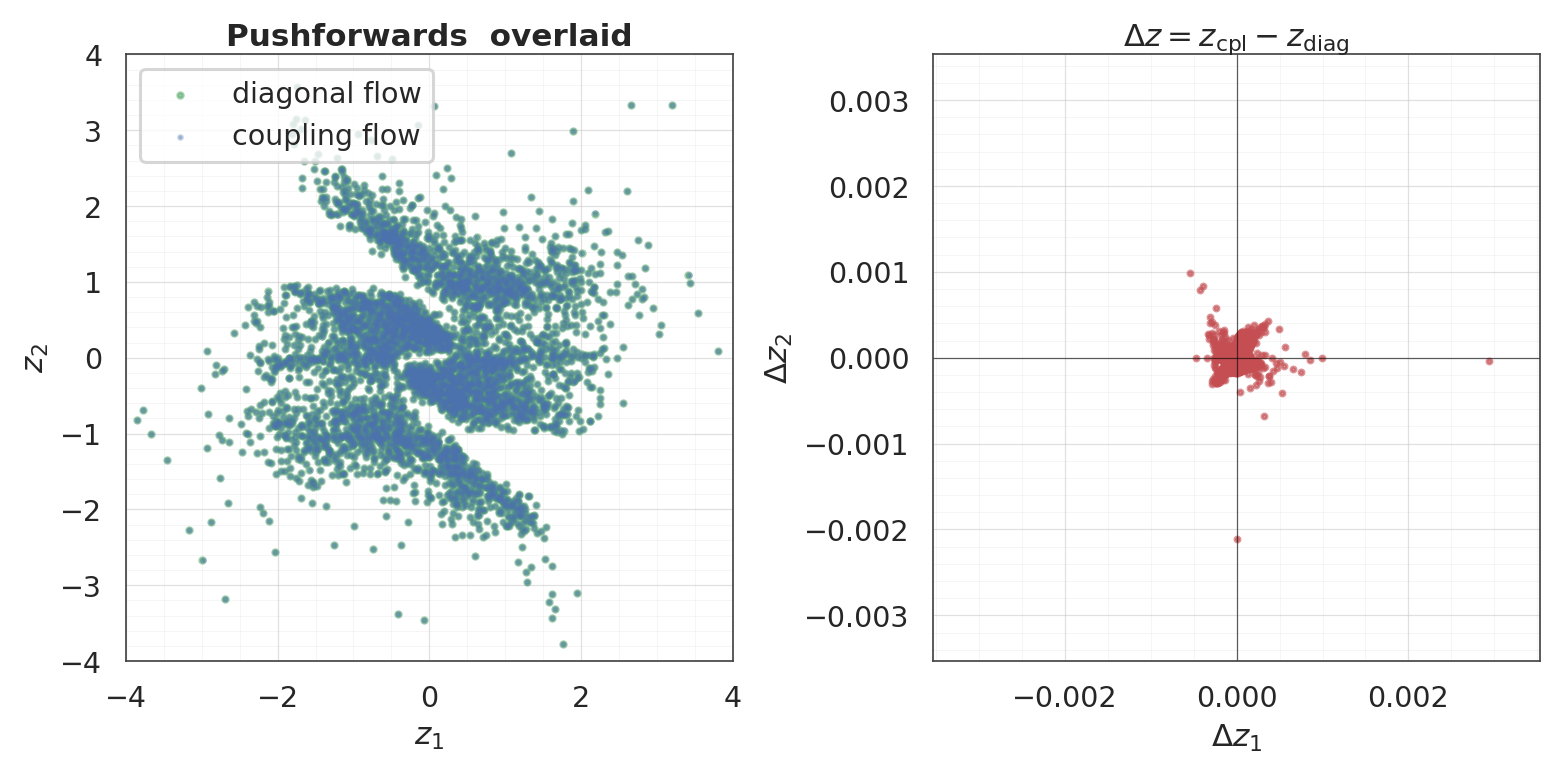

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.scatter(
    Z_diag[:, 0],
    Z_diag[:, 1],
    s=12,
    alpha=0.55,
    color=COLOR_DIAG,
    label="diagonal flow",
)
ax.scatter(
    Z_cpl[:, 0], Z_cpl[:, 1], s=5, alpha=0.35, color=COLOR_CPL, label="coupling flow"
)
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Pushforwards  overlaid")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.legend(loc="upper left", frameon=True)
style_axes(ax, aspect="equal")

ax = axes[1]
delta = Z_cpl - Z_diag
lim = max(1e-5, float(np.max(np.abs(delta))) * 1.2)
ax.scatter(delta[:, 0], delta[:, 1], s=10, alpha=0.6, color=COLOR_DELTA)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\Delta z_1$")
ax.set_ylabel(r"$\Delta z_2$")
ax.set_title(r"$\Delta z = z_{\mathrm{cpl}} - z_{\mathrm{diag}}$")
style_axes(ax, aspect="equal")

plt.show()

Both dims agree to within accumulated float32 drift ($\lesssim 10^{-2}$) and the log-probs agree to the same order. The coupling flow behaves **numerically identically** to the diagonal flow — the conditioner contributes nothing at init time because its final kernel is zero, and the flip-aware seeding means both branches fit the *same* mixture on the *same* original dim.

### Conditioner kernel sanity check

Dig into each coupling in the flow and read out $\max |W|$ on its conditioner's final Dense. All should be exactly zero at RBIG init.

In [5]:
def iter_couplings(flow):
    chain = flow.bijection.bijection  # Invert -> Chain
    for bij in chain.bijections:
        if isinstance(bij, MixtureGaussianCDFCoupling):
            yield bij


max_W_init = [
    float(jnp.max(jnp.abs(bij._coupling.conditioner.layers[-1].weight)))
    for bij in iter_couplings(flow_cpl)
]
print("max |W| on each coupling's final Dense at RBIG init:")
for i, w in enumerate(max_W_init):
    print(f"  coupling {i:>2d}: {w:.2e}")
print(f"overall max |W| = {max(max_W_init):.2e}")

max |W| on each coupling's final Dense at RBIG init:
  coupling  0: 0.00e+00
  coupling  1: 0.00e+00
  coupling  2: 0.00e+00
  coupling  3: 0.00e+00
  coupling  4: 0.00e+00
  coupling  5: 0.00e+00
  coupling  6: 0.00e+00
  coupling  7: 0.00e+00
overall max |W| = 0.00e+00


## 5. Training breaks the equivalence

One gradient step of the coupling flow sets its final-Dense kernels $W$ to nonzero values. The conditioner stops being constant-in-$x_a$, and the layer becomes a genuinely conditional transform. From that point on, $f_\text{cpl}$ diverges from $f_\text{diag}$.

Train only the coupling flow (the diagonal flow stays frozen as the reference). Re-check the pointwise error after a handful of epochs.

In [6]:
flow_cpl_trained, losses = fit_to_data(
    jr.key(1),
    flow_cpl,
    X,
    learning_rate=3e-4,
    max_epochs=20,
    max_patience=20,
    batch_size=512,
    val_prop=0.1,
    show_progress=False,
)

Z_cpl_trained = np.asarray(jax.vmap(flow_cpl_trained.bijection.inverse)(X))
err_trained = np.linalg.norm(Z_cpl_trained - Z_diag, axis=-1)
lp_cpl_trained = np.asarray(jax.vmap(flow_cpl_trained.log_prob)(X))
lp_err_trained = np.abs(lp_cpl_trained - lp_diag)

print("after 20 epochs of coupling-flow training:")
print()
print("pushforward difference  ||z_cpl - z_diag||_2")
print(f"  median : {np.median(err_trained):.2e}")
print(f"  95th%  : {np.percentile(err_trained, 95):.2e}")
print(f"  max    : {err_trained.max():.2e}")
print()
print("log-prob difference     |log p_cpl(x) - log p_diag(x)|")
print(f"  median : {np.median(lp_err_trained):.2e}")
print(f"  95th%  : {np.percentile(lp_err_trained, 95):.2e}")
print(f"  max    : {lp_err_trained.max():.2e}")
print()
print(f"mean log-likelihood  diagonal (frozen)  = {lp_diag.mean():+.3f} nats/sample")
print(
    f"mean log-likelihood  coupling (trained) = {lp_cpl_trained.mean():+.3f} nats/sample"
)

after 20 epochs of coupling-flow training:

pushforward difference  ||z_cpl - z_diag||_2
  median : 1.69e-01
  95th%  : 5.02e-01
  max    : 2.98e+00

log-prob difference     |log p_cpl(x) - log p_diag(x)|
  median : 5.63e-01
  95th%  : 1.47e+00
  max    : 9.58e+00

mean log-likelihood  diagonal (frozen)  = -2.198 nats/sample
mean log-likelihood  coupling (trained) = -1.837 nats/sample


### Conditioner kernel after training

Same readout as above, but after gradient steps. The zero-init is gone — every coupling now has a nonzero $W$, which means the conditioner is no longer constant-in-$x_a$.

In [7]:
max_W_trained = [
    float(jnp.max(jnp.abs(bij._coupling.conditioner.layers[-1].weight)))
    for bij in iter_couplings(flow_cpl_trained)
]
print("max |W| on each coupling's final Dense after training:")
for i, w in enumerate(max_W_trained):
    print(f"  coupling {i:>2d}: {w:.2e}")
print(f"overall max |W| = {max(max_W_trained):.2e}")

max |W| on each coupling's final Dense after training:
  coupling  0: 2.29e-02
  coupling  1: 3.21e-02
  coupling  2: 2.41e-02
  coupling  3: 2.97e-02
  coupling  4: 3.18e-02
  coupling  5: 2.79e-02
  coupling  6: 3.95e-02
  coupling  7: 2.69e-02
overall max |W| = 3.95e-02


### Visualise the divergence

Same two panels, *after* training. Now the overlay shows two visibly different point clouds, and $\Delta z$ fills a non-trivial region of the plane — the conditioner has learnt cross-dim structure the diagonal flow cannot express.

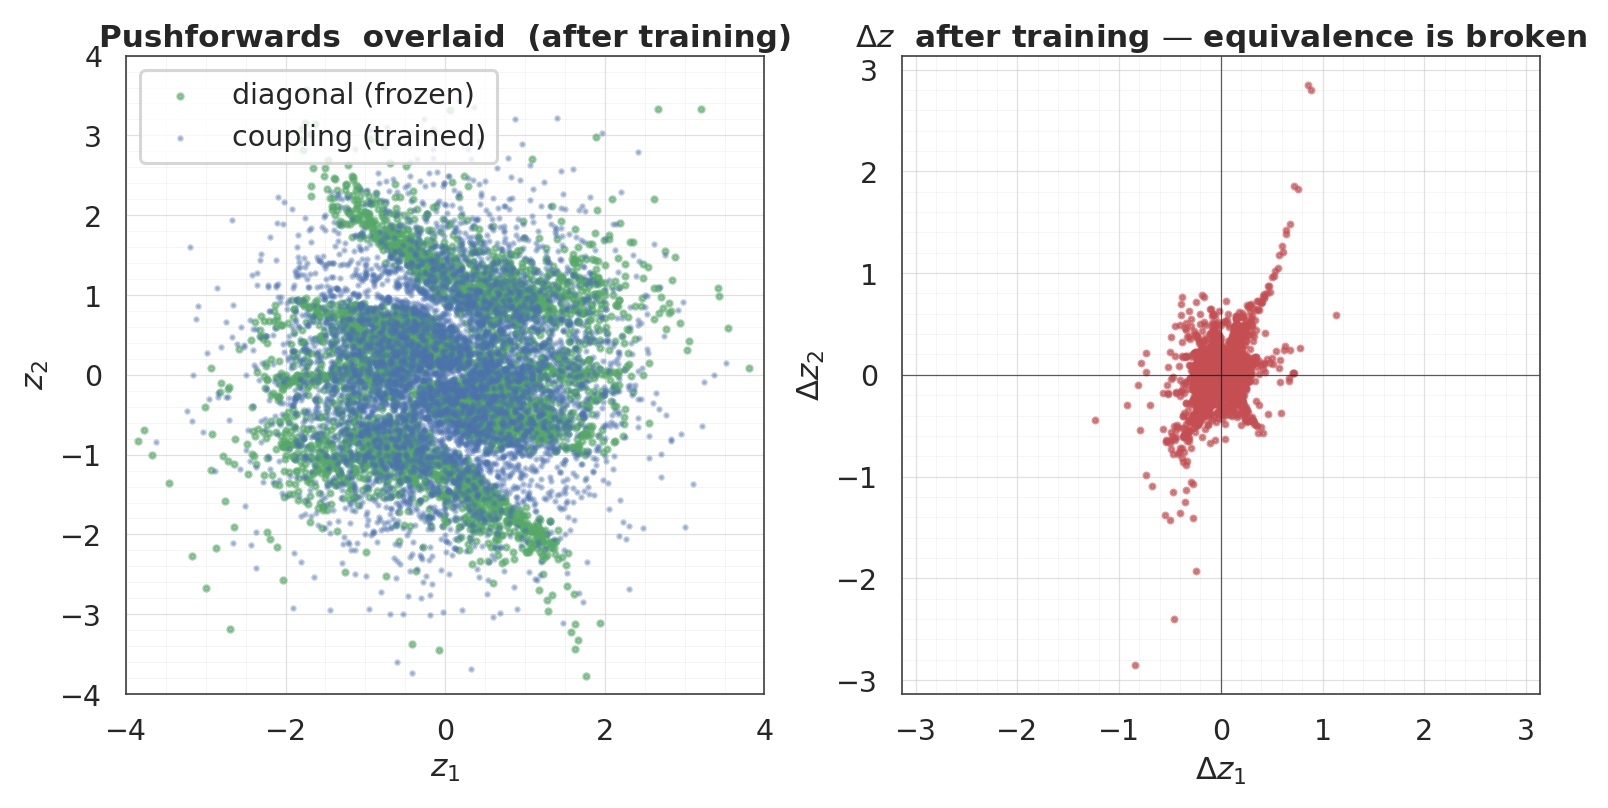

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.scatter(
    Z_diag[:, 0],
    Z_diag[:, 1],
    s=12,
    alpha=0.55,
    color=COLOR_DIAG,
    label="diagonal (frozen)",
)
ax.scatter(
    Z_cpl_trained[:, 0],
    Z_cpl_trained[:, 1],
    s=5,
    alpha=0.35,
    color=COLOR_CPL,
    label="coupling (trained)",
)
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Pushforwards  overlaid  (after training)")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.legend(loc="upper left", frameon=True)
style_axes(ax, aspect="equal")

ax = axes[1]
delta_trained = Z_cpl_trained - Z_diag
lim = max(0.05, float(np.max(np.abs(delta_trained))) * 1.1)
ax.scatter(delta_trained[:, 0], delta_trained[:, 1], s=10, alpha=0.6, color=COLOR_DELTA)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\Delta z_1$")
ax.set_ylabel(r"$\Delta z_2$")
ax.set_title(r"$\Delta z$  after training — equivalence is broken")
style_axes(ax, aspect="equal")

plt.show()

### Error magnitudes side-by-side

One bar chart comparing the pointwise $L_2$ error and log-prob difference, before vs after training. Log scale on the y-axis because the two regimes differ by 6+ orders of magnitude.

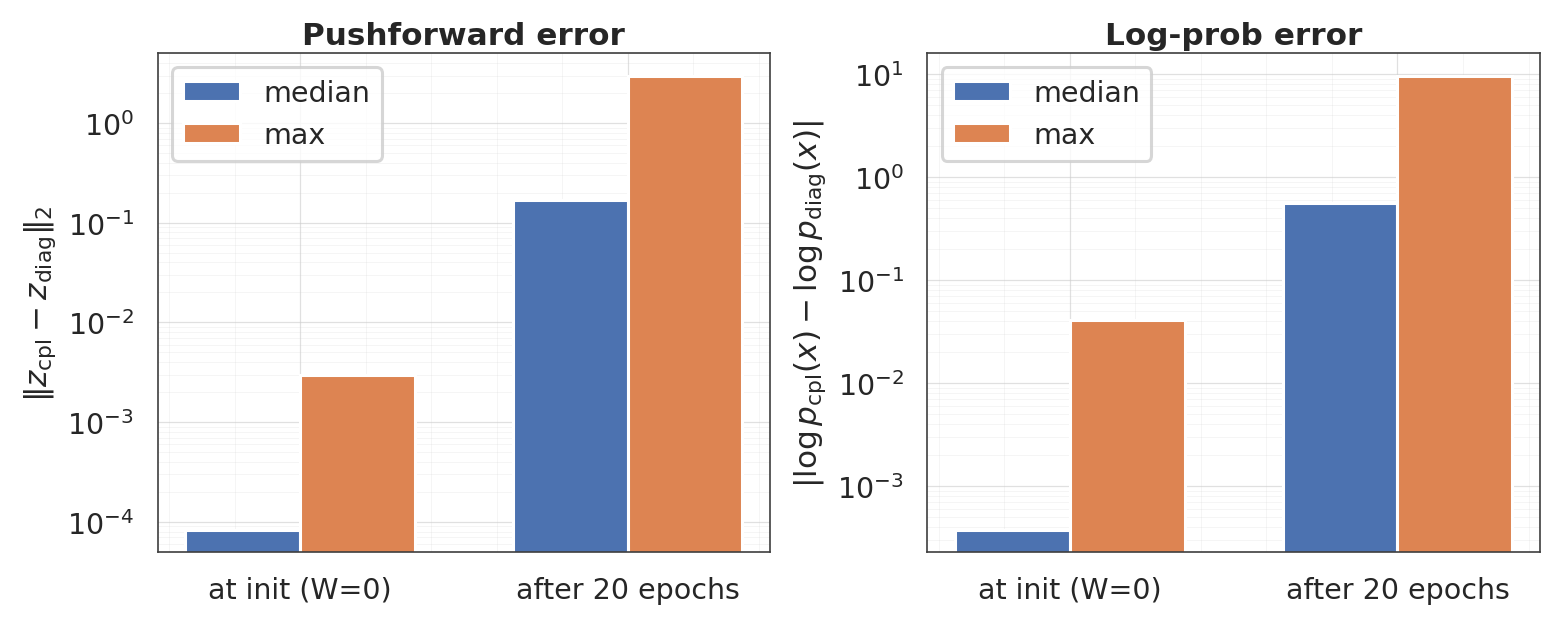

In [9]:
stats = {
    "at init (W=0)": (err, lp_err),
    "after 20 epochs": (err_trained, lp_err_trained),
}
labels = list(stats.keys())
err_medians = [np.median(stats[k][0]) for k in labels]
err_maxs = [stats[k][0].max() for k in labels]
lp_medians = [np.median(stats[k][1]) for k in labels]
lp_maxs = [stats[k][1].max() for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
width = 0.35
x = np.arange(len(labels))

ax = axes[0]
ax.bar(x - width / 2, err_medians, width, label="median", color=palette[0])
ax.bar(x + width / 2, err_maxs, width, label="max", color=palette[1])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\|z_\mathrm{cpl} - z_\mathrm{diag}\|_2$")
ax.set_title("Pushforward error")
ax.legend(loc="upper left", frameon=True)
style_axes(ax)

ax = axes[1]
ax.bar(x - width / 2, lp_medians, width, label="median", color=palette[0])
ax.bar(x + width / 2, lp_maxs, width, label="max", color=palette[1])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$|\log p_\mathrm{cpl}(x) - \log p_\mathrm{diag}(x)|$")
ax.set_title("Log-prob error")
ax.legend(loc="upper left", frameon=True)
style_axes(ax)

plt.show()

## Takeaways

- At zero-kernel init the coupling flow is a **reparameterisation** of a diagonal Gaussianization flow, which itself is the parametric form of RBIG. Three different architectures, one function — numerically equal up to small accumulated float error.
- The only freedom unused at init is the conditioner's final kernel $W$. Training lets that kernel grow, which is exactly what turns a diagonal Gaussianization into a genuinely conditional coupling flow.
- Practical implication: when using `fit_rbig_coupling`, you can think of the first forward pass as "here is RBIG" and of training as "now refine RBIG with cross-dim modulation". The warm-start doesn't constrain the eventual model — only the starting point.